#1: Training model recognition table

In [ ]:
# ── Imports ───────────────────────────────────────────────
import torch
import random
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
import timm

import os, gc, time, shutil, subprocess, json
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

In [ ]:
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")
ds1_img  = BASE / "table_segmentation_1/data/images"
ds1_mask = BASE / "table_segmentation_1/data/masks"
ds2_mask = BASE / "table_segmentation_2/data/masks"
ds3_mask = BASE / "table_segmentation_3/data/masks"

# Gom tất cả IDs có mask
all_mask_ids = set()
for mask_dir in [ds1_mask, ds2_mask, ds3_mask]:
    for f in mask_dir.glob("*_row.png"):
        all_mask_ids.add(f.stem.replace("_row", ""))

# IDs có image
all_img_ids = set(f.stem for f in ds1_img.glob("*.png"))

print(f"Total mask IDs: {len(all_mask_ids):,}")
print(f"Total image IDs: {len(all_img_ids):,}")
print(f"IDs có cả image lẫn mask: {len(all_mask_ids & all_img_ids):,}")
print(f"IDs có mask nhưng không có image: {len(all_mask_ids - all_img_ids):,}")
print(f"IDs có image nhưng không có mask: {len(all_img_ids - all_mask_ids):,}")

Total mask IDs: 30,000
Total image IDs: 30,000
IDs có cả image lẫn mask: 30,000
IDs có mask nhưng không có image: 0
IDs có image nhưng không có mask: 0


In [ ]:
# ── Config ────────────────────────────────────────────────
BATCH_SIZE = 8
IMG_SIZE = 384
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Đường dẫn ─────────────────────────────────────────────
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")

IMG_DIR = BASE / "table_segmentation_1/data/images"

MASK_DIR_DILATED = BASE / "masks_dilated"

# Build lookup: sid → mask_dir
mask_dir_lookup = {}
for f in MASK_DIR_DILATED.glob("*_row.png"):
    sid = f.stem.replace("_row", "")
    mask_dir_lookup[sid] = MASK_DIR_DILATED

all_ids = sorted(mask_dir_lookup.keys())

print(f"Images:      {len(list(IMG_DIR.glob('*.png'))):,}")
print(f"Mask lookup: {len(mask_dir_lookup):,}")
print(f"Total IDs:   {len(all_ids):,}")
print(f"Device:      {device}")
# ── CELL 2: Dataset ───────────────────────────────────────
class TableDataset(Dataset):
    MASK_TYPES = ["row", "col", "col_header", "row_header", "span"]

    def __init__(self, sample_ids, augment=False):
        self.sample_ids = sample_ids
        self.augment    = augment

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]
    
        img  = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
        mask_dir = mask_dir_lookup[sid]  # tự động chọn đúng thư mục
    
        masks = {}
        for mtype in self.MASK_TYPES:
            p = mask_dir / f"{sid}_{mtype}.png"
            masks[mtype] = Image.open(p).convert("L") if p.exists() \
                else Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE), np.uint8))
    
        if self.augment:
            img, masks = self._augment(img, masks)

        img = TF.resize(img, (IMG_SIZE, IMG_SIZE), 
                    interpolation=TF.InterpolationMode.BILINEAR)
        masks = {k: TF.resize(v, (IMG_SIZE, IMG_SIZE),
                    interpolation=TF.InterpolationMode.NEAREST)
             for k, v in masks.items()}
    
        img_t  = TF.to_tensor(img)
        mask_t = torch.cat([
            (TF.to_tensor(masks[m]) > 0.5).float()
            for m in self.MASK_TYPES
        ], dim=0)
        return {"image": img_t, "masks": mask_t, "sample_id": sid}

    def _augment(self, img, masks):
        all_imgs = [img] + list(masks.values())
    
        # Rotate nhiều hơn
        if random.random() > 0.5:
            angle = random.uniform(-3, 3)  
            all_imgs = [TF.rotate(i, angle) for i in all_imgs]
    
        # Horizontal flip (giữ)
        if random.random() > 0.5:
            all_imgs = [TF.hflip(i) for i in all_imgs]
    
        # Brightness/contrast (giữ)
        if random.random() > 0.5:
            all_imgs[0] = TF.adjust_brightness(all_imgs[0], random.uniform(0.7, 1.3))
            all_imgs[0] = TF.adjust_contrast(all_imgs[0], random.uniform(0.7, 1.3))
    
        img = all_imgs[0]
        for k, key in enumerate(masks.keys()):
            masks[key] = all_imgs[k+1]
        return img, masks

# Split train/val
random.seed(42)
random.shuffle(all_ids)
n_val     = int(len(all_ids) * 0.1)
train_ids = all_ids[:-n_val]
val_ids   = all_ids[-n_val:]

train_ds = TableDataset(train_ids, augment=True)
val_ds   = TableDataset(val_ids,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Verify 1 batch
batch = next(iter(train_loader))
print(f"Image shape: {batch['image'].shape}")
print(f"Masks shape: {batch['masks'].shape}")
print(f"Masks unique: {batch['masks'].unique().tolist()}")

Images:      30,000
Mask lookup: 30,000
Total IDs:   30,000
Device:      cpu
Train: 27,000 | Val: 3,000
Train batches: 3375 | Val batches: 375
Image shape: torch.Size([8, 3, 384, 384])
Masks shape: torch.Size([8, 5, 384, 384])
Masks unique: [0.0, 1.0]


Sample: sample_000445
Image size: (256, 256)


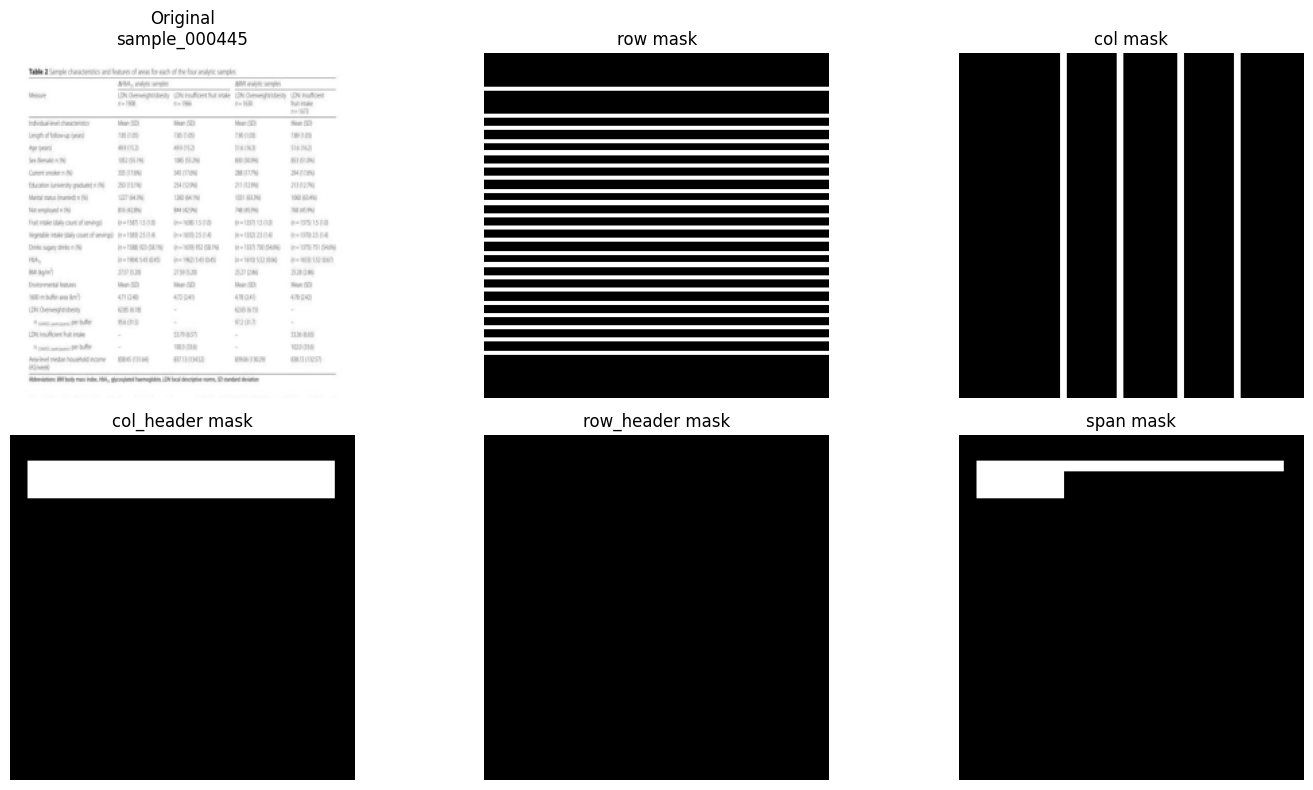


📊 Mask stats:
  row         : 25.8% white pixels
  col         : 7.8% white pixels
  col_header  : 9.7% white pixels
  row_header  : 0.0% white pixels
  span        : 4.8% white pixels


In [ ]:
# Lấy 1 sample ngẫu nhiên
sample_ids = [f.stem for f in sorted(IMG_DIR.glob("*.png"))]
sid = random.choice(sample_ids)
print(f"Sample: {sid}")

# Load ảnh
img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
print(f"Image size: {img.size}")

# Load và visualize 5 masks
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
mask_names = ["row", "col", "col_header", "row_header", "span"]

axes[0, 0].imshow(img)
axes[0, 0].set_title(f"Original\n{sid}")
axes[0, 0].axis("off")

for i, mtype in enumerate(mask_names):
    ax = axes[(i+1)//3, (i+1)%3]
    p  = mask_dir_lookup[sid] / f"{sid}_{mtype}.png"  
    if p.exists():
        mask = Image.open(p).convert("L")
        ax.imshow(mask, cmap="gray")
        ax.set_title(f"{mtype} mask")
    else:
        ax.set_title(f"{mtype} — NOT FOUND")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Thống kê masks
print("\n📊 Mask stats:")
for mtype in mask_names:
    p = mask_dir_lookup[sid] / f"{sid}_{mtype}.png" 
    if p.exists():
        mask_arr = np.array(Image.open(p).convert("L"))
        white_pct = (mask_arr > 128).sum() / mask_arr.size * 100
        print(f"  {mtype:<12}: {white_pct:.1f}% white pixels")
    else:
        print(f"  {mtype:<12}: NOT FOUND")

In [ ]:
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")

# Tạo folder mới
NEW_MASK_DIR = BASE / "masks_dilated"

mask_dir_lookup = {
    f.stem.replace("_row", ""): NEW_MASK_DIR
    for f in NEW_MASK_DIR.glob("*_row.png")
}

all_ids = sorted(mask_dir_lookup.keys())
print(f"✅ mask_dir_lookup → {NEW_MASK_DIR}")
print(f"Total IDs in new lookup: {len(all_ids):,}")
print(f"Total masks: {len(list(NEW_MASK_DIR.glob('*.png'))):,}")

✅ mask_dir_lookup → /Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/masks_dilated
Total IDs in new lookup: 30,000
Total masks: 149,826


In [ ]:
sample_check = random.sample(all_ids, 10)
for sid in sample_check:
    p = NEW_MASK_DIR / f"{sid}_col.png"
    if p.exists():
        mask = np.array(Image.open(p).convert("L"))
        pct = (mask > 128).mean() * 100
        print(f"{sid}: {pct:.1f}%")
    else:
        print(f"{sid}: col mask NOT FOUND")

sample_004517: 7.4%
sample_024544: 8.2%
sample_012594: 4.7%
sample_002414: 9.4%
sample_024243: 7.0%
sample_017518: 2.7%
sample_009869: 7.0%
sample_000538: 5.9%
sample_004251: 7.8%
sample_012254: 20.7%


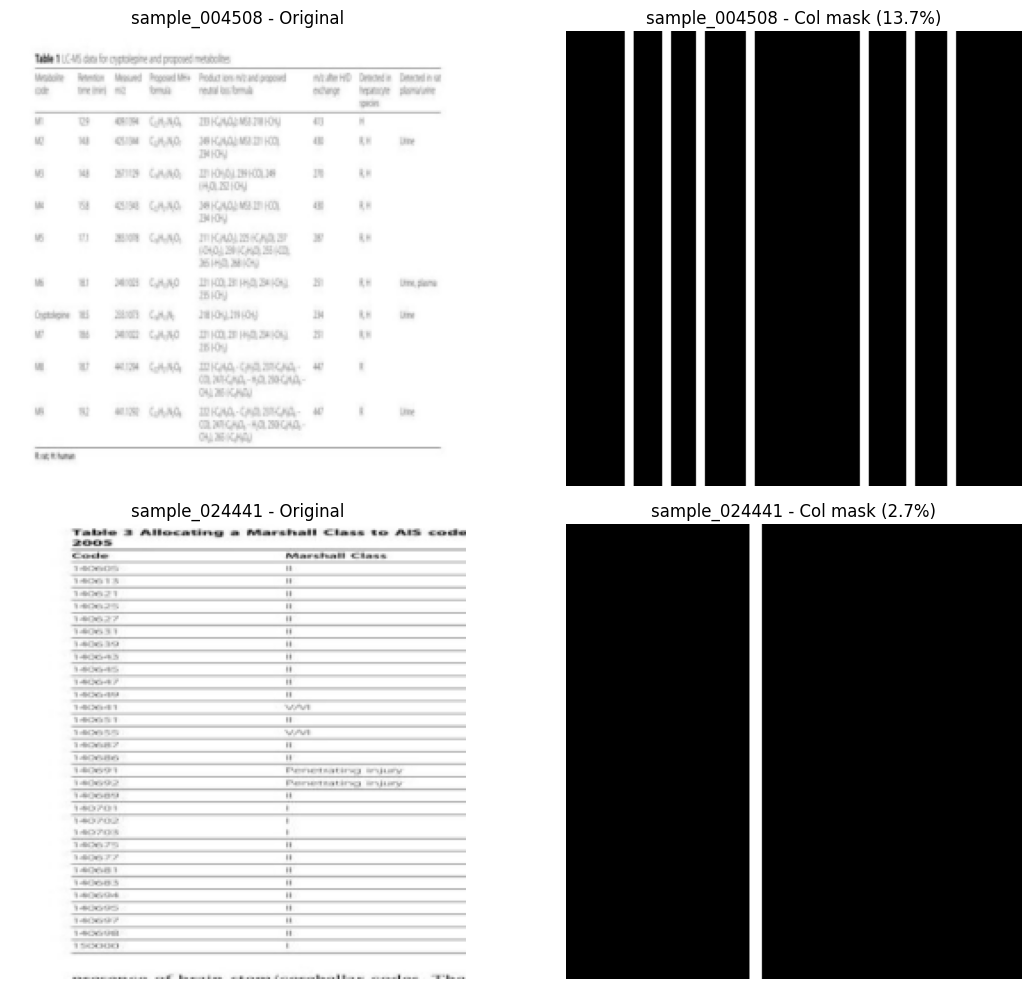

In [ ]:
suspicious = ["sample_004508", "sample_024441"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, sid in enumerate(suspicious):
    # Ảnh gốc
    img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{sid} - Original")
    axes[i, 0].axis("off")

    # Col mask sau dilate
    mask = Image.open(NEW_MASK_DIR / f"{sid}_col.png").convert("L")
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"{sid} - Col mask ({(np.array(mask)>128).mean()*100:.1f}%)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 3: EfficientNet-B4 + UNet Decoder ───────────────
class EfficientUNet(nn.Module):
    def __init__(self, out_ch=5, pretrained=True):
        super().__init__()

        # ── Encoder: EfficientNet-B4 ──────────────────
        self.encoder = timm.create_model(
            "efficientnet_b4",
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3, 4),
        )
        # EfficientNet-B4 channel sizes: 24, 32, 56, 160, 448
        enc_chs = self.encoder.feature_info.channels() 

        # ── Bottleneck ────────────────────────────────
        self.bottleneck = nn.Sequential(
            nn.Conv2d(enc_chs[4], 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # ── Decoder blocks ────────────────────────────
        self.dec4 = self._dec_block(256 + enc_chs[3], 128)
        self.dec3 = self._dec_block(128 + enc_chs[2], 64)
        self.dec2 = self._dec_block(64  + enc_chs[1], 32)
        self.dec1 = self._dec_block(32  + enc_chs[0], 16)
        self.dec0 = self._dec_block(16, 16)  

        # ── Output ────────────────────────────────────
        self.out_conv = nn.Conv2d(16, out_ch, 1)

    def _dec_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        feats = self.encoder(x)  # [s0,s1,s2,s3,s4]
        s0, s1, s2, s3, s4 = feats

        # Bottleneck
        b = self.bottleneck(s4)

        # Decoder + skip connections
        x = F.interpolate(b,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec4(torch.cat([x, s3], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec3(torch.cat([x, s2], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec2(torch.cat([x, s1], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec1(torch.cat([x, s0], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec0(x)

        return self.out_conv(x)


# ── Verify ────────────────────────────────────────────────
model = EfficientUNet(out_ch=5, pretrained=False).to(device)
dummy = torch.randn(2, 3, 384, 384).to(device)
with torch.no_grad():
    out = model(dummy)

total = sum(p.numel() for p in model.parameters())
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")
print(f"Params: {total/1e6:.1f}M")
print(f"Output size match: {out.shape[-2:] == torch.Size([384, 384])}")

Input:  torch.Size([2, 3, 384, 384])
Output: torch.Size([2, 5, 384, 384])
Params: 19.2M
Output size match: True


In [ ]:
model = timm.create_model('efficientnet_b4', features_only=True)
for f in model.feature_info:
    print(f)

{'stage': 1, 'reduction': 2, 'module': 'blocks.0', 'num_chs': 24, 'index': 0}
{'stage': 2, 'reduction': 4, 'module': 'blocks.1', 'num_chs': 32, 'index': 1}
{'stage': 3, 'reduction': 8, 'module': 'blocks.2', 'num_chs': 56, 'index': 2}
{'stage': 5, 'reduction': 16, 'module': 'blocks.4', 'num_chs': 160, 'index': 3}
{'stage': 7, 'reduction': 32, 'module': 'blocks.6', 'num_chs': 448, 'index': 4}


In [ ]:
def boundary_loss(pred, target, kernel_size=3):
    """Penalize lỗi tại boundary nhiều hơn"""
    pad = kernel_size // 2
    # Tính boundary của target bằng erosion
    eroded = -F.max_pool2d(-target, kernel_size, stride=1, padding=pad)
    boundary = target - eroded  # chỉ giữ lại viền

    bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    
    # Tăng weight tại vùng boundary
    weight = 1.0 + 5.0 * boundary
    return (bce * weight).mean()

class DiceFocalLoss(nn.Module):
    def __init__(self, focal_weight=0.4, boundary_weight=0.2, alpha=0.75, gamma=2.0):
        super().__init__()
        self.focal_w = focal_weight
        self.boundary_w = boundary_weight
        self.dice_w     = 1 - focal_weight - boundary_weight
        self.alpha = alpha
        self.gamma = gamma
        # Trọng số: [row, col, col_header, row_header, span]
        self.channel_weights = torch.tensor([2.0, 2.0, 1.0, 4.0, 6.0])

    def forward(self, pred, target):
        weights = self.channel_weights.to(pred.device)
        total = 0
        for i in range(pred.shape[1]):
            p = pred[:, i:i+1]
            t = target[:, i:i+1]
            
            # 1. Tính Focal Loss (xử lý viền mỏng)
            bce = F.binary_cross_entropy_with_logits(p, t, reduction='none')
            pt = torch.exp(-bce)
            focal_loss = (self.alpha * (1 - pt) ** self.gamma * bce).mean()
            
            # 2. Tính Dice Loss (xử lý IoU tổng thể)
            pred_sig = torch.sigmoid(p).reshape(-1)
            t_flat = t.reshape(-1)
            inter = (pred_sig * t_flat).sum()
            eps = 1e-6
            dice_loss = 1 - (2*inter+eps)/(pred_sig.sum()+t_flat.sum()+eps)
            b_loss = boundary_loss(p, t)
            
            # 3. Tổng hợp lại có nhân trọng số channel
            total += weights[i] * (
                self.focal_w * focal_loss +
                self.dice_w  * dice_loss  +
                self.boundary_w * b_loss
            )
            
        return total / pred.shape[1]
        
def compute_miou(pred_logits, target, threshold=0.5, thresholds=None):
    names = ["row","col","col_header","row_header","span"]
    ious  = {}
    for i, name in enumerate(names):
        thr  = thresholds[name] if thresholds else threshold
        pred = (torch.sigmoid(pred_logits[:, i]) > thr).float()
        p    = pred.reshape(-1)
        t    = target[:, i].reshape(-1)
        inter = (p*t).sum()
        union = (p+t-p*t).sum()
        ious[name] = (inter/union).item() if union >= 1 else float("nan")
    valid        = [v for v in ious.values() if not np.isnan(v)]
    ious["mean"] = np.mean(valid) if valid else 0.0
    return ious

def find_best_thresholds(model, loader, device):
    model.eval()
    all_preds = {i: [] for i in range(5)}
    all_masks  = {i: [] for i in range(5)}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = torch.sigmoid(model(imgs))
            for i in range(5):
                all_preds[i].append(preds[:,i].cpu())
                all_masks[i].append(masks[:,i].cpu())
    names = ["row","col","col_header","row_header","span"]
    best_thresholds = {}
    for i, name in enumerate(names):
        p_all = torch.cat(all_preds[i]).reshape(-1).numpy()
        t_all = torch.cat(all_masks[i]).reshape(-1).numpy()
        best_iou, best_thr = 0, 0.5
        for thr in np.arange(0.1, 0.9, 0.02):
            p_bin = (p_all > thr).astype(float)
            inter = (p_bin * t_all).sum()
            union = (p_bin + t_all - p_bin * t_all).sum()
            iou   = inter / union if union > 0 else 0
            if iou > best_iou:
                best_iou, best_thr = iou, thr
        best_thresholds[name] = best_thr
        print(f"  {name}: best_thr={best_thr:.2f} → IoU={best_iou:.4f}")
    return best_thresholds

scaler = torch.amp.GradScaler('cuda')

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0
    for batch in loader:
        imgs, masks = batch["image"].to(device), batch["masks"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = criterion(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total    = 0
    all_ious = {n:[] for n in ["row","col","col_header","row_header","span"]}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = model(imgs)
            total += criterion(preds, masks).item()
            for name, val in compute_miou(preds, masks).items():
                if name != "mean" and not np.isnan(val):
                    all_ious[name].append(val)
    avg_ious         = {n: np.mean(v) if v else 0.0 for n,v in all_ious.items()}
    avg_ious["mean"] = np.mean(list(avg_ious.values()))
    return total/len(loader), avg_ious

print("✅ Hàm đã định nghĩa xong!")

✅ Hàm đã định nghĩa xong!


In [ ]:
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
gc.collect()
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True

# ── Config ────────────────────────────────────────────────
LR_FT     = 2e-6
EPOCHS_FT = 80    
patience  = 15    
CKPT_DIR   = Path("/kaggle/working/checkpoints_effb4_ft")
CKPT_DIR.mkdir(exist_ok=True)
BACKUP_DIR = Path("/kaggle/working/checkpoint_backup_ft")
BACKUP_DIR.mkdir(exist_ok=True)

scaler = torch.amp.GradScaler('cuda')

# ── DataLoader ────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── Load best model ───────────────────────────────────────
CKPT_SRC = Path("/kaggle/input/table-seg-checkpoints-v2")
ckpt = torch.load(CKPT_SRC / "best_model.pt", map_location=device, weights_only=False)
model = EfficientUNet(out_ch=5, pretrained=False).to(device)
model.load_state_dict(ckpt["model"])
print(f"✅ Loaded epoch={ckpt['epoch']} | mIoU={ckpt['best_miou']:.4f}")

# ── Loss ──────────────────────────────────────────────────
criterion = DiceFocalLoss(focal_weight=0.4, boundary_weight=0.2, alpha=0.75, gamma=2.0).to(device)

# ── Optimizer ─────────────────────────────────────────────
optimizer = AdamW([
    {"params": model.encoder.parameters(),    "lr": LR_FT * 0.3},
    {"params": model.bottleneck.parameters(), "lr": LR_FT},
    {"params": model.dec4.parameters(),       "lr": LR_FT},
    {"params": model.dec3.parameters(),       "lr": LR_FT},
    {"params": model.dec2.parameters(),       "lr": LR_FT},
    {"params": model.dec1.parameters(),       "lr": LR_FT},
    {"params": model.dec0.parameters(),       "lr": LR_FT},
    {"params": model.out_conv.parameters(),   "lr": LR_FT},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-8
)

best_miou  = ckpt["best_miou"]
history_ft = ckpt["history"]
no_improve = 0 
START      = ckpt["epoch"] + 1
END        = START + 30

# ── Tạo dataset backup TRƯỚC khi train ───────────────────
meta_path = BACKUP_DIR / "dataset-metadata.json"
with open(meta_path, "w") as f:
    json.dump({
        "title": "table-seg-checkpoints-v2",
        "id": "tiinh123/table-seg-checkpoints-v2",
        "licenses": [{"name": "CC0-1.0"}]
    }, f)

# Copy checkpoint gốc vào backup rồi create dataset
check = subprocess.run([
    "kaggle", "datasets", "files",
    "tiinh123/table-seg-checkpoints-v2"
], capture_output=True, text=True)

if check.returncode == 0:
    print(f"✅ Dataset đã tồn tại, sẵn sàng backup")
else:
    shutil.copy2(CKPT_SRC / "best_model.pt", BACKUP_DIR / "best_model.pt")
    result = subprocess.run([
        "kaggle", "datasets", "create",
        "-p", str(BACKUP_DIR),
        "--dir-mode", "tar"
    ], capture_output=True, text=True)
    if "being created" in result.stdout:
        print(f"✅ Dataset created!")
    else:
        print(f"⚠️ {result.stdout[:100]}")

print(f"\nFine-tuning epoch {START} → {END-1} | lr={LR_FT}\n")

# ── Training loop ─────────────────────────────────────────
for epoch in range(START, END):
    t          = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_ious = validate(model, val_loader, criterion, device)
    scheduler.step()
    miou = val_ious["mean"]

    history_ft["train_loss"].append(train_loss)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_miou"].append(miou)

    print(f"Epoch {epoch:2d} | Train={train_loss:.4f} Val={val_loss:.4f} mIoU={miou:.4f} | {time.time()-t:.0f}s")

    if epoch % 5 == 0:
        print(f"  row={val_ious['row']:.3f} | col={val_ious['col']:.3f} | "
              f"hdr={val_ious['col_header']:.3f} | rhdr={val_ious['row_header']:.3f} | span={val_ious['span']:.3f}")

    # Save checkpoint local
    ckpt_new = {
        "epoch":      epoch,
        "model":      model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "history":    history_ft,
        "best_miou":  best_miou,
        "no_improve": no_improve,
    }
    torch.save(ckpt_new, CKPT_DIR / "last_checkpoint.pt")

    # Backup mỗi 5 epoch
    if epoch % 5 == 0:
        torch.save(ckpt_new, CKPT_DIR / f"checkpoint_epoch{epoch}.pt")
        shutil.copy2(CKPT_DIR / "last_checkpoint.pt", BACKUP_DIR / "last_checkpoint.pt")
        result = subprocess.run([
            "kaggle", "datasets", "version",
            "-p", str(BACKUP_DIR),
            "-m", f"epoch{epoch}-miou{miou:.4f}", 
            "--dir-mode", "tar"
        ], capture_output=True, text=True)

        if "Upload successful" in result.stderr or "successful" in result.stdout.lower():
            print(f"  💾 Saved + ☁️ Backed up epoch{epoch}")
        else:
            print(f"  ⚠️ Backup: {result.stdout[:80]}")

    # Best model
    if miou > best_miou:
        best_miou  = miou
        no_improve = 0
        torch.save(ckpt_new, CKPT_DIR / "best_model.pt")
        shutil.copy2(CKPT_DIR / "best_model.pt", BACKUP_DIR / "best_model.pt")

        result = subprocess.run([
            "kaggle", "datasets", "version",
            "-p", str(BACKUP_DIR),
            "-m", f"BEST-epoch{epoch}-miou{best_miou:.4f}",
            "--dir-mode", "tar"
        ], capture_output=True, text=True)

        if "Upload successful" in result.stderr or "successful" in result.stdout.lower():
            print(f"  ✅ Best saved + backed up (mIoU={best_miou:.4f})")
        else:
            print(f"  ⚠️ Backup status unknown: {result.stdout[:100]}")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"⛔ Early stopping epoch {epoch}")
            break

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft["train_loss"], label="Train")
axes[0].plot(history_ft["val_loss"],   label="Val")
axes[0].set_title("Fine-tune Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_ft["val_miou"], color="green", label="mIoU")
axes[1].axhline(0.80, color="red", linestyle="--", label="Target 0.80")
axes[1].set_title("Fine-tune mIoU"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ Fine-tune done! Best mIoU: {best_miou:.4f}")

Train batches: 3375 | Val batches: 375
✅ Loaded epoch=92 | mIoU=0.7962
✅ Dataset đã tồn tại, sẵn sàng backup

Fine-tuning epoch 93 → 122 | lr=2e-06

Epoch 93 | Train=0.2879 Val=0.7665 mIoU=0.7869 | 878s
Epoch 94 | Train=0.2877 Val=0.6298 mIoU=0.7849 | 776s
Epoch 95 | Train=0.2885 Val=0.7199 mIoU=0.7815 | 776s
  row=0.795 | col=0.770 | hdr=0.892 | rhdr=0.728 | span=0.723
  💾 Saved + ☁️ Backed up epoch95
Epoch 96 | Train=0.2850 Val=0.4032 mIoU=0.7882 | 775s
Epoch 97 | Train=0.2875 Val=0.3549 mIoU=0.7941 | 776s
Epoch 98 | Train=0.2862 Val=0.4154 mIoU=0.7860 | 776s
Epoch 99 | Train=0.2839 Val=0.9072 mIoU=0.7888 | 776s
Epoch 100 | Train=0.2895 Val=0.4168 mIoU=0.7876 | 776s
  row=0.797 | col=0.775 | hdr=0.896 | rhdr=0.740 | span=0.730
  💾 Saved + ☁️ Backed up epoch100
Epoch 101 | Train=0.2822 Val=0.3522 mIoU=0.7935 | 775s
Epoch 102 | Train=0.2859 Val=0.3561 mIoU=0.7917 | 779s
Epoch 103 | Train=0.2829 Val=0.3929 mIoU=0.7881 | 776s
Epoch 104 | Train=0.2883 Val=0.3548 mIoU=0.7927 | 775s


In [ ]:
# 1. Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2/best_model_v2.pt")

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model_eval = EfficientUNet(out_ch=5, pretrained=False).to(device)
model_eval.load_state_dict(ckpt["model"])
model_eval.eval()

print(f"✅ Đã load Model từ epoch {ckpt['epoch']} (mIoU cũ: {ckpt['best_miou']:.4f})")

if 'history' in ckpt:
    val_miou_history = ckpt['history']['val_miou']
    print(f"📈 Số lượng Epoch đã lưu trong lịch sử: {len(val_miou_history)}")
    print(f"📊 5 Epoch cuối cùng: {val_miou_history[-5:]}")
    
    # Tìm giá trị lớn nhất trong lịch sử xem có khớp 0.7962 không
    max_in_history = max(val_miou_history)
    print(f"🏆 Giá trị cao nhất trong lịch sử: {max_in_history:.4f}")

# 2. Chuẩn bị DataLoader (Sử dụng val_ds đã có của bạn)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

In [346]:
# Hàm load model
def load_model(path, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model = EfficientUNet(out_ch=5, pretrained=False).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model, ckpt

# Đường dẫn
best_path = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2/best_model_v2.pt")
last_path = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2/last_checkpoint_v2.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model_best, ckpt_best = load_model(best_path, device)
print(f"✅ Load best model epoch {ckpt_best['epoch']} (mIoU: {ckpt_best['best_miou']:.4f})")

if last_path.exists():
    model_last, ckpt_last = load_model(last_path, device)
    print(f"✅ Load last model epoch {ckpt_last['epoch']}")
else:
    print("⚠️ Last checkpoint not found, using best model")
    model_last = model_best

# Hàm validate 
def validate_current_performance(model, loader, device, name="Model"):
    model.eval()
    total_inter = np.zeros(5)
    total_union = np.zeros(5)
    names = ["row", "col", "col_header", "row_header", "span"]
    print(f"⏳ Đang tính toán mIoU thực tế cho {name}...")
    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            masks = batch["masks"].to(device).cpu().numpy()
            preds = (torch.sigmoid(model(imgs)) > 0.5).cpu().numpy().astype(np.float32)
            for i in range(5):
                inter = (preds[:, i] * masks[:, i]).sum()
                union = (preds[:, i] + masks[:, i] - preds[:, i] * masks[:, i]).sum()
                total_inter[i] += inter
                total_union[i] += union
    print(f"\n==============================================")
    print(f"📊 KẾT QUẢ INFERENCE THỰC TẾ: {name}")
    print(f"==============================================")
    mious = []
    for i in range(5):
        iou = total_inter[i] / total_union[i] if total_union[i] > 0 else 0
        mious.append(iou)
        print(f"🔹 {names[i]:12}: {iou:.4f}")
    current_miou = np.mean(mious)
    print(f"----------------------------------------------")
    print(f"🔥 mIoU TỔNG THỰC TẾ : {current_miou:.4f}")
    print(f"==============================================\n")
    return current_miou

# Sử dụng val_loader có sẵn
miou_best_actual = validate_current_performance(model_best, val_loader, device, name="BEST MODEL")
miou_last_actual = validate_current_performance(model_last, val_loader, device, name="LAST MODEL")

✅ Load best model epoch 92 (mIoU: 0.7962)
✅ Load last model epoch 120
⏳ Đang tính toán mIoU thực tế cho BEST MODEL...

📊 KẾT QUẢ INFERENCE THỰC TẾ: BEST MODEL
🔹 row         : 0.6492
🔹 col         : 0.7843
🔹 col_header  : 0.9032
🔹 row_header  : 0.8003
🔹 span        : 0.7165
----------------------------------------------
🔥 mIoU TỔNG THỰC TẾ : 0.7707

⏳ Đang tính toán mIoU thực tế cho LAST MODEL...

📊 KẾT QUẢ INFERENCE THỰC TẾ: LAST MODEL
🔹 row         : 0.7217
🔹 col         : 0.6790
🔹 col_header  : 0.8934
🔹 row_header  : 0.7957
🔹 span        : 0.7067
----------------------------------------------
🔥 mIoU TỔNG THỰC TẾ : 0.7593



In [347]:
# Bộ ngưỡng lấy từ kết quả Ensemble
opt_thresholds = {
    "row": 0.65,
    "col": 0.50,
    "col_header": 0.45,
    "row_header": 0.30,
    "span": 0.65
}

In [348]:
def validate_ensemble_performance(model_a, model_b, loader, device, thresholds=None):
    model_a.eval()
    model_b.eval()
    
    total_inter = np.zeros(5)
    total_union = np.zeros(5)
    names = ["row", "col", "col_header", "row_header", "span"]
    
    # Nếu không có ngưỡng tối ưu, mặc định dùng 0.5
    if thresholds is None:
        thresholds = {n: 0.5 for n in names}
    
    print("⏳ Đang tính toán mIoU cho bộ ENSEMBLE (Best + Last)...")
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            masks = batch["masks"].to(device).cpu().numpy()
            
            # Lấy xác suất từ 2 mô hình
            prob_a = torch.sigmoid(model_a(imgs))
            prob_b = torch.sigmoid(model_b(imgs))
            
            # Kết hợp xác suất (Trung bình cộng)
            avg_probs = (prob_a + prob_b) / 2
            avg_probs = avg_probs.cpu().numpy()
            
            for i, name in enumerate(names):
                thr = thresholds[name]
                p_bin = (avg_probs[:, i] > thr).astype(np.float32)
                t_bin = masks[:, i]
                
                inter = (p_bin * t_bin).sum()
                union = (p_bin + t_bin - p_bin * t_bin).sum()
                total_inter[i] += inter
                total_union[i] += union
                
    print(f"\n==============================================")
    print(f"🏆 KẾT QUẢ ENSEMBLE CUỐI CÙNG")
    print(f"==============================================")
    mious = []
    for i, name in enumerate(names):
        iou = total_inter[i] / total_union[i] if total_union[i] > 0 else 0
        mious.append(iou)
        print(f"🔹 {name:12}: {iou:.4f} (Thr: {thresholds[name]})")
    
    ensemble_miou = np.mean(mious)
    print(f"----------------------------------------------")
    print(f"🔥 mIoU ENSEMBLE TỔNG : {ensemble_miou:.4f}")
    print(f"==============================================\n")
    return ensemble_miou

# --- THỰC THI ---
miou_final = validate_ensemble_performance(model_best, model_last, val_loader, device, thresholds=opt_thresholds)
print(f"🏆 Ensemble mIoU: {miou_final:.4f}")

⏳ Đang tính toán mIoU cho bộ ENSEMBLE (Best + Last)...

🏆 KẾT QUẢ ENSEMBLE CUỐI CÙNG
🔹 row         : 0.7231 (Thr: 0.65)
🔹 col         : 0.7474 (Thr: 0.5)
🔹 col_header  : 0.8990 (Thr: 0.45)
🔹 row_header  : 0.8011 (Thr: 0.3)
🔹 span        : 0.7190 (Thr: 0.65)
----------------------------------------------
🔥 mIoU ENSEMBLE TỔNG : 0.7779

🏆 Ensemble mIoU: 0.7779


In [ ]:
history_data = ckpt['history']

print("Kiểu dữ liệu của history:", type(history_data))

# 1. Nếu history là một danh sách các epoch (List of dicts)
if isinstance(history_data, list):
    for log in history_data:
        # Tìm đúng log của epoch 92
        if log.get('epoch', -1) == ckpt['epoch']: 
            print("\n🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆")
            for k, v in log.items():
                print(f"➤ {k:<15}: {v}")
            break

# 2. Nếu history là một từ điển chứa các mảng (Dict of lists)
elif isinstance(history_data, dict):
    print("\nCác thông số được lưu trong history:", history_data.keys())
    print("\n🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆")
    
    # Epoch 92 thường nằm ở vị trí index 91 (nếu lưu từ epoch 1)
    # hoặc index cuối cùng nếu lúc lưu best model bạn update history
    index_epoch = ckpt['epoch'] - 1 
    
    for key, values_list in history_data.items():
        if isinstance(values_list, list) and len(values_list) > index_epoch:
            val = values_list[index_epoch]
            # Format in cho đẹp nếu là số thập phân
            if isinstance(val, float):
                print(f"➤ {key:<15}: {val:.4f}")
            else:
                print(f"➤ {key:<15}: {val}")

Kiểu dữ liệu của history: <class 'dict'>

Các thông số được lưu trong history: dict_keys(['train_loss', 'val_loss', 'val_miou'])

🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆
➤ train_loss     : 0.2643
➤ val_loss       : 0.3186
➤ val_miou       : 0.7974


#2: Use model when training done

In [ ]:
selected_img_path = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images/sample_00085.png"

In [ ]:
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2
from PIL import Image

def straighten_row_mask(row_mask, min_width_ratio=0.25, line_thickness=1):
    H, W = row_mask.shape
    proj = row_mask.sum(axis=1).astype(float)
    threshold = W * min_width_ratio
    active = (proj > threshold).astype(np.uint8)
    straightened = np.zeros_like(row_mask)
    
    in_region, start = False, 0
    for y in range(H):
        if active[y] and not in_region:
            in_region, start = True, y
        elif not active[y] and in_region:
            in_region = False
            center = (start + y) // 2
            # line_thickness=1 → chỉ 1px thay vì 3px
            half = line_thickness // 2
            straightened[max(0, center-half):center+half+1, :] = 1
    if in_region:
        center = (start + H) // 2
        half = line_thickness // 2
        straightened[max(0, center-half):center+half+1, :] = 1
    return straightened


def straighten_col_mask(col_mask, min_height_ratio=0.25, line_thickness=1):
    H, W = col_mask.shape
    proj = col_mask.sum(axis=0).astype(float)
    threshold = H * min_height_ratio
    active = (proj > threshold).astype(np.uint8)
    straightened = np.zeros_like(col_mask)
    
    in_region, start = False, 0
    for x in range(W):
        if active[x] and not in_region:
            in_region, start = True, x
        elif not active[x] and in_region:
            in_region = False
            center = (start + x) // 2
            half = line_thickness // 2
            straightened[:, max(0, center-half):center+half+1] = 1
    if in_region:
        center = (start + W) // 2
        half = line_thickness // 2
        straightened[:, max(0, center-half):center+half+1] = 1
    return straightened


def visualize_ensemble_masks(image_path, model_1, model_2, device, thresholds, img_size=384):
    orig_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = orig_img.size

    scale = img_size / max(orig_w, orig_h)
    new_w, new_h = int(orig_w * scale), int(orig_h * scale)
    draft = orig_img.resize((new_w, new_h), Image.BILINEAR)
    padded = Image.new("RGB", (img_size, img_size), (255, 255, 255))
    padded.paste(draft, (0, 0))
    img_t = TF.to_tensor(padded).unsqueeze(0).to(device)

    model_1.eval(); model_2.eval()
    with torch.no_grad():
        preds_1 = torch.sigmoid(model_1(img_t)).squeeze(0)
        preds_2 = torch.sigmoid(model_2(img_t)).squeeze(0)
        avg_preds = ((preds_1 + preds_2) / 2).cpu().numpy()

    # ── Raw masks (không gian effective) ──────────────────────────────
    row_mask_raw  = (avg_preds[0] > thresholds["row"]).astype(np.uint8)
    col_mask_raw  = (avg_preds[1] > thresholds["col"]).astype(np.uint8)
    span_mask_raw = (avg_preds[4] > thresholds["span"]).astype(np.uint8)

    # ── Straighten trong không gian effective ──────────────────────────
    row_straight  = straighten_row_mask(row_mask_raw[:new_h, :new_w],  min_width_ratio=0.25)
    col_straight  = straighten_col_mask(col_mask_raw[:new_h, :new_w],  min_height_ratio=0.25)

    # ── Resize tất cả về ảnh gốc ──────────────────────────────────────
    def to_orig(mask):
        return cv2.resize(mask.astype(np.uint8), (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    row_orig      = to_orig(row_mask_raw[:new_h, :new_w])
    col_orig      = to_orig(col_mask_raw[:new_h, :new_w])
    span_orig     = to_orig(span_mask_raw[:new_h, :new_w])
    row_str_orig  = to_orig(row_straight)
    col_str_orig  = to_orig(col_straight)

    img_np = np.array(orig_img)

    # ── Hàm vẽ overlay ────────────────────────────────────────────
    def make_overlay(base, r_mask, c_mask, s_mask, alpha=0.45):
        out = base.astype(np.float32).copy()
        out[s_mask > 0] = out[s_mask > 0] * (1 - 0.25) + np.array([100, 149, 237]) * 0.25
        row_thick = cv2.dilate(r_mask, np.ones((3,1), np.uint8), iterations=1)
        out[row_thick > 0] = out[row_thick > 0] * (1 - alpha) + np.array([220, 30, 30]) * alpha
        col_thick = cv2.dilate(c_mask, np.ones((1,3), np.uint8), iterations=1)
        out[col_thick > 0] = out[col_thick > 0] * (1 - alpha) + np.array([30, 180, 30]) * alpha
        return np.clip(out, 0, 255).astype(np.uint8)

    overlay_raw  = make_overlay(img_np, row_orig,     col_orig,     span_orig)
    overlay_str  = make_overlay(img_np, row_str_orig, col_str_orig, span_orig)

    # ── Hàm render mask đẹp (binary → màu) ───────────────────────────
    def render_mask(mask, color_rgb, base=None):
        """Vẽ mask lên nền trắng hoặc lên ảnh gốc."""
        H, W = mask.shape
        canvas = np.ones((H, W, 3), dtype=np.uint8) * 245
        if base is not None:
            canvas = base.copy()
        thick = cv2.dilate(mask, np.ones((3,3), np.uint8), iterations=1)
        canvas[thick > 0] = color_rgb
        return canvas

    row_vis  = render_mask(row_str_orig,  [210, 40,  40])
    col_vis  = render_mask(col_str_orig,  [30,  160, 30])
    span_vis = render_mask(span_orig,     [60,  100, 220])

    # ── Plot ──────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 11))
    fig.patch.set_facecolor('#1a1a2e')

    titles = [
        "① Original", "② Row (straight)", "③ Col (straight)",
        "④ Span", "⑤ Overlay – raw mask", "⑥ Overlay – straightened"
    ]
    images = [img_np, row_vis, col_vis, span_vis, overlay_raw, overlay_str]

    for i, (title, im) in enumerate(zip(titles, images)):
        ax = fig.add_subplot(2, 3, i + 1)
        ax.imshow(im)
        ax.set_title(title, color='white', fontsize=11, pad=6, fontweight='bold')
        ax.axis('off')
        # Viền màu theo loại
        border_colors = ['#aaaaaa','#dd3333','#33bb33','#4466dd','#ff9944','#44ddaa']
        for spine in ax.spines.values():
            spine.set_edgecolor(border_colors[i])
            spine.set_linewidth(2.5)
            spine.set_visible(True)

    # Legend
    legend_items = [
        mpatches.Patch(color='#dd3333', label='Row separator'),
        mpatches.Patch(color='#33bb33', label='Col separator'),
        mpatches.Patch(color='#6464dd', label='Span cell'),
    ]
    fig.legend(handles=legend_items, loc='lower center', ncol=3,
               fontsize=10, facecolor='#2a2a4a', labelcolor='white',
               edgecolor='gray', framealpha=0.9,
               bbox_to_anchor=(0.5, 0.01))

    thr_text = (f"row={thresholds['row']}  col={thresholds['col']}  "
                f"span={thresholds['span']}  |  "
                f"img: {orig_w}×{orig_h}px  →  effective: {new_w}×{new_h}")
    fig.text(0.5, 0.965, thr_text, ha='center', va='top',
             color='#cccccc', fontsize=9)

    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()
    
    # ── In thống kê ───────────────────────────────────────────────────
    def count_lines(straight_mask, axis):
        proj = straight_mask.sum(axis=axis)
        return int((proj > 0).sum())
    
    n_rows = count_lines(row_str_orig, axis=1)
    n_cols = count_lines(col_str_orig, axis=0)
    print(f"Detected: {n_rows} row lines, {n_cols} col lines → "
          f"~{max(0,n_rows-1)}×{max(0,n_cols-1)} cells")

visualize_ensemble_masks(selected_img_path, model_best, model_last, device, opt_thresholds)

  → 8 rows, 5 cols

=== DEBUG CELLS ROW 1 ===
  col 0: span=1x1, x=0, y=18, w=96, h=17
  col 1: span=1x1, x=96, y=18, w=99, h=17
  col 2: span=1x1, x=196, y=18, w=103, h=17
  col 3: span=1x1, x=299, y=18, w=106, h=17
  col 4: span=1x1, x=406, y=18, w=96, h=17


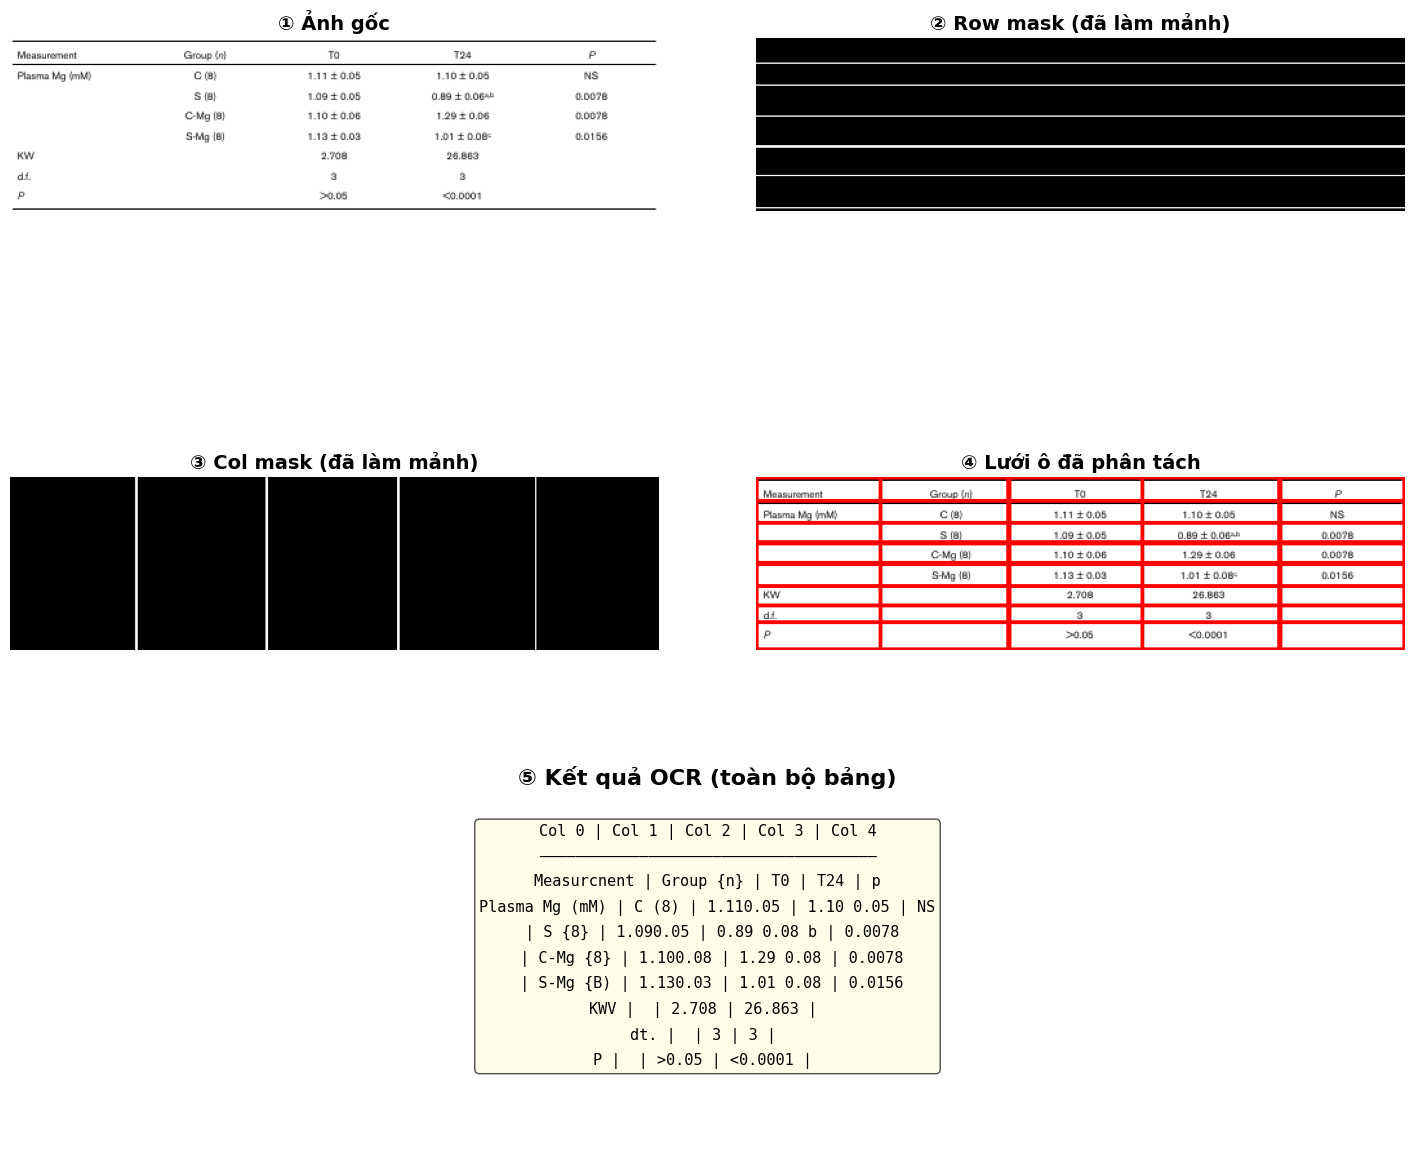

In [ ]:
def illustrate_pipeline_grid(image_path, model1, model2, device, thresholds, ocr, upscale=2.5, img_size=384):
    # ── 1. Ảnh gốc ────────────────────────────────────────
    orig_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = orig_img.size

    # ── 2. Tạo mask giống pipeline ────────────────────────
    scale = img_size / max(orig_w, orig_h)
    new_w, new_h = int(orig_w*scale), int(orig_h*scale)
    draft = orig_img.resize((new_w, new_h), Image.BILINEAR)
    padded = Image.new("RGB", (img_size, img_size), (255,255,255))
    padded.paste(draft, (0,0))
    img_t = TF.to_tensor(padded).unsqueeze(0).to(device)

    model1.eval(); model2.eval()
    with torch.no_grad():
        p1 = torch.sigmoid(model1(img_t))
        p2 = torch.sigmoid(model2(img_t))
        preds = ((p1 + p2) / 2).squeeze(0).cpu().numpy()

    row_mask = (preds[0] > thresholds["row"]).astype(np.uint8)
    col_mask = (preds[1] > thresholds["col"]).astype(np.uint8)

    # ── 3. Straighten masks ──────────────────────────────
    row_str = straighten_row_mask(row_mask[:new_h, :new_w], min_width_ratio=0.10)
    col_str = straighten_col_mask(col_mask[:new_h, :new_w], min_height_ratio=0.25)

    row_orig = cv2.resize(row_str, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    col_orig = cv2.resize(col_str, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # ── 4. Tạo grid và OCR ───────────────────────────────
    cells = masks_to_cell_boxes_v2(row_mask, col_mask,
                                   orig_w, orig_h, img_size,
                                   effective_w=new_w, effective_h=new_h,
                                   orig_img_pil=orig_img)
    cells = crop_and_ocr_fast(orig_img, cells, ocr, upscale=upscale)

    # ── 5. Vẽ bố cục 2-2-1 ──────────────────────────────
    fig = plt.figure(figsize=(18, 16))
    fig.patch.set_facecolor('white')

    # Tạo lưới 3 hàng, 2 cột với height_ratios: hàng 1 và 2 bằng nhau, hàng 3 to gấp đôi
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.9], hspace=0.12, wspace=0.15)

    # (a) ① Ảnh gốc
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(orig_img)
    ax0.set_title("① Ảnh gốc", fontsize=14, fontweight='bold')
    ax0.axis('off')

    # (b) ② Row mask
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(row_orig, cmap='gray')
    ax1.set_title("② Row mask (đã làm mảnh)", fontsize=14, fontweight='bold')
    ax1.axis('off')

    # (c) ③ Col mask
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.imshow(col_orig, cmap='gray')
    ax2.set_title("③ Col mask (đã làm mảnh)", fontsize=14, fontweight='bold')
    ax2.axis('off')

    # (d) ④ Lưới ô
    overlay = np.array(orig_img).copy()
    for cell in cells:
        cv2.rectangle(overlay, (cell.x, cell.y), (cell.x+cell.w, cell.y+cell.h), (255,0,0), 2)
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.imshow(overlay)
    ax3.set_title("④ Lưới ô đã phân tách", fontsize=14, fontweight='bold')
    ax3.axis('off')

    # (e) ⑤ OCR – kéo dài toàn bộ hàng dưới
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('off')
    ax4.set_title("⑤ Kết quả OCR (toàn bộ bảng)", fontsize=16, fontweight='bold', pad=15)

    max_row = max(c.row_idx for c in cells) + 1
    max_col = max(c.col_idx for c in cells) + 1

    text_lines = []
    for r in range(max_row):
        row_texts = []
        for c in range(max_col):
            cell = next((x for x in cells if x.row_idx==r and x.col_idx==c), None)
            row_texts.append(cell.text if cell else "")
        text_lines.append(" | ".join(row_texts))

    header = " | ".join(["Col "+str(i) for i in range(max_col)])
    text_lines.insert(0, header)
    text_lines.insert(1, "─"*len(header))

    full_text = "\n".join(text_lines)
   # Grid
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.8], hspace=0.12, wspace=0.2)

    # OCR text
    ax4.text(0.5, 0.95, full_text,
            ha='center', va='top',
            fontfamily='monospace', fontsize=11,
            linespacing=1.8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
            transform=ax4.transAxes)

    plt.show()

# Gọi hàm
illustrate_pipeline_grid(selected_img_path, model_best, model_last, device, opt_thresholds, ocr)

In [ ]:
import numpy as np
import cv2
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from dataclasses import dataclass
from typing import List

@dataclass
class Cell:
    row_idx: int
    col_idx: int
    x: int; y: int; w: int; h: int
    row_span: int = 1 
    col_span: int = 1 
    is_span: bool = False
    text: str = ""

In [ ]:
def detect_rows_from_whitespace(pil_img, orig_w, orig_h, img_size=384,
                                effective_w=None, effective_h=None):
    """
    Trả về danh sách vị trí Y (trong không gian ảnh gốc) của các đường phân cách hàng
    dựa vào projection dọc của ảnh xám.
    """
    if effective_w is None: effective_w = img_size
    if effective_h is None: effective_h = img_size

    gray = np.array(pil_img.convert('L'))           
    v_proj = gray.sum(axis=1).astype(np.float64)
    norm = v_proj / (v_proj.max() + 1e-6)
    is_blank = norm > 0.85

    min_gap = max(2, int(orig_h * 0.005))  
    lines = []
    in_gap, start = False, 0
    for i, v in enumerate(is_blank):
        if v and not in_gap:
            in_gap, start = True, i
        elif not v and in_gap:
            in_gap = False
            mid = (start + i) // 2
            if not lines or mid - lines[-1] >= min_gap:
                lines.append(mid)
    if in_gap:
        mid = (start + len(is_blank) - 1) // 2
        if not lines or mid - lines[-1] >= min_gap:
            lines.append(mid)
    return lines   

def detect_cols_from_whitespace(orig_img_pil, row_sep, orig_w, orig_h,
                                 img_size, effective_w, effective_h):
    """
    khi col_mask yếu → tìm cột bằng vertical whitespace
    """
    img_np = np.array(orig_img_pil.convert("L")) 
    H, W   = img_np.shape

    _, bw = cv2.threshold(img_np, 200, 255, cv2.THRESH_BINARY)

    vert_proj = (bw < 200).sum(axis=0).astype(float)

    vert_proj = np.convolve(vert_proj,
                            np.ones(5)/5, mode='same')

    threshold = vert_proj.max() * 0.05
    is_space  = vert_proj < threshold

    col_dividers = []
    in_space, start = False, 0
    for i, v in enumerate(is_space):
        if v and not in_space:
            in_space, start = True, i
        elif not v and in_space:
            in_space = False
            width = i - start
            if width > 8:  
                col_dividers.append((start + i) // 2)

    return [0] + col_dividers + [W]

In [ ]:
def masks_to_cell_boxes_v2(row_mask, col_mask,
                           orig_w, orig_h, img_size=384,
                           effective_w=None, effective_h=None,
                           orig_img_pil=None) -> List[Cell]:
    if effective_w is None: effective_w = img_size
    if effective_h is None: effective_h = img_size

    row_mask = row_mask[:effective_h, :effective_w]
    col_mask = col_mask[:effective_h, :effective_w]

    # ── THAY ĐỔI: dùng straighten mask thay vì dilate ──
    row_straight = straighten_row_mask(row_mask, min_width_ratio=0.25) 
    # Projection từ straighten mask (đường mảnh 1px)
    h_proj = row_straight.sum(axis=1).astype(float)

    # Phần cột vẫn giữ nguyên (nhưng có thể cần giảm kernel nếu quá to)
    v_lines = cv2.morphologyEx(col_mask*255, cv2.MORPH_OPEN,
                               np.ones((effective_h//8, 1), np.uint8))  # kernel cao 12 px
    v_lines = cv2.dilate(v_lines, np.ones((3,3), np.uint8), iterations=1)
    v_proj = v_lines.sum(axis=0).astype(float)

    # ── Hàm tìm vị trí từ projection ──
    def mask_to_positions(proj, effective_dim, min_gap_ratio=0.02, threshold_ratio=0.01):
        # Các tham số có thể giữ như cũ
        min_gap = max(3, int(effective_dim * min_gap_ratio))
        norm = proj / (proj.max() + 1e-6)
        is_line = norm > threshold_ratio
        lines, in_line, start = [], False, 0
        for i, v in enumerate(is_line):
            if v and not in_line:
                in_line, start = True, i
            elif not v and in_line:
                in_line = False
                mid = (start + i) // 2
                if not lines or mid - lines[-1] >= min_gap:
                    lines.append(mid)
        if in_line:
            mid = (start + len(is_line) - 1) // 2
            if not lines or mid - lines[-1] >= min_gap:
                lines.append(mid)
        return lines

    row_lines = mask_to_positions(h_proj, effective_dim=effective_h,
                                  min_gap_ratio=0.01, threshold_ratio=0.02)
    col_lines = mask_to_positions(v_proj, effective_dim=effective_w,
                                  min_gap_ratio=0.02, threshold_ratio=0.05)
    
    min_dist_to_bottom = max(3, int(effective_h * 0.03))
    row_lines = [l for l in row_lines if (effective_h - l) > min_dist_to_bottom]

    row_sep = [0] + row_lines + [effective_h]

    if orig_img_pil is not None:
        # Số hàng kỳ vọng tối thiểu (có thể tuỳ chỉnh, ở đây để 5)
        MIN_EXPECTED_ROWS = 5
        # Chiều cao trung bình hàng hiện tại
        avg_h = effective_h / max(1, len(row_sep)-1)
        last_h = row_sep[-1] - row_sep[-2]

        if len(row_sep)-1 < MIN_EXPECTED_ROWS or last_h > 2.5 * avg_h:
            # Lấy tất cả vị trí dòng trắng từ ảnh gốc
            white_lines = detect_rows_from_whitespace(
                orig_img_pil, orig_w, orig_h,
                img_size, effective_w, effective_h
            )
            # Chuyển về không gian effective
            white_lines_eff = [int(y * effective_h / orig_h) for y in white_lines]
            # Chỉ lấy những đường nằm trong vùng còn thiếu (sau đường cuối cùng của mask)
            if white_lines_eff:
                # Lọc các đường nằm giữa row_sep[-2] và effective_h
                extra = [e for e in white_lines_eff if row_sep[-2] < e < effective_h]
                if extra:
                    # Sắp xếp và thêm vào row_sep (loại bỏ phần tử effective_h cuối, rồi thêm lại)
                    row_sep = row_sep[:-1] + extra + [effective_h]
                    # Sắp xếp lại toàn bộ cho chắc
                    row_sep = sorted(set(row_sep))
            print(f"  → Bổ sung whitespace rows, tổng {len(row_sep)-1} hàng")

    # ── Kiểm tra col_mask có đủ mạnh không ──────────────
    col_mask_strength = col_mask.sum() / (effective_w * effective_h)

    if col_mask_strength < 0.01 or len(col_lines) < 1:
        # col_mask quá yếu → fallback dùng whitespace
        print("  ⚠️ col_mask yếu, dùng whitespace detection")
        sx = orig_w / effective_w
        sy = orig_h / effective_h
        col_sep_orig = detect_cols_from_whitespace(
            orig_img_pil, row_sep, orig_w, orig_h,
            img_size, effective_w, effective_h
        )
        # Convert về không gian mask
        col_sep = [int(x / (orig_w/effective_w)) for x in col_sep_orig]
        col_sep = [0] + [c for c in col_sep if 0 < c < effective_w] + [effective_w]
    else:
        col_sep = [0] + col_lines + [effective_w]

    print(f"  → {len(row_sep)-1} rows, {len(col_sep)-1} cols")

    sx = orig_w / effective_w
    sy = orig_h / effective_h
    cells = []
    for r in range(len(row_sep) - 1):
        for c in range(len(col_sep) - 1):
            x1, x2 = col_sep[c], col_sep[c+1]
            y1, y2 = row_sep[r], row_sep[r+1]
            cells.append(Cell(
                row_idx=r, col_idx=c,
                x=int(x1*sx), y=int(y1*sy),
                w=int((x2-x1)*sx), h=int((y2-y1)*sy)
            ))
    print("\n=== DEBUG CELLS ROW 1 ===")
    for c in cells:
        if c.row_idx == 1:
            print(f"  col {c.col_idx}: span={c.row_span}x{c.col_span}, x={c.x}, y={c.y}, w={c.w}, h={c.h}")

    return cells

In [ ]:
from paddleocr import PaddleOCR

# Bạn cần biết 2 đường dẫn này từ kết quả fine-tune
REC_MODEL_DIR = "/Users/macbookpro14m1pro/Desktop/RagTable/data/inference_model"   # thư mục chứa model rec

ocr = PaddleOCR(
    use_textline_orientation=False,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    lang="en",
    # ── Load model fine-tune ──────────────────
    # text_recognition_model_dir=REC_MODEL_DIR,
)

In [ ]:
import concurrent.futures
import numpy as np
import cv2
import re
from paddleocr import PaddleOCR

def clean_text(text, col_idx=None):
    if not text:
        return ""
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s\.\,\-\+\*/=<>()\[\]{}^_%:;!?@#$&/]', '', text)
    return text

def process_single_cell(cell, img_np, H, W, ocr, upscale):
    pad = int(min(cell.w, cell.h) * 0.1)
    x1 = max(0, cell.x - pad); y1 = max(0, cell.y - pad)
    x2 = min(W, cell.x + cell.w + pad); y2 = min(H, cell.y + cell.h + pad)
    crop = img_np[y1:y2, x1:x2]
    if crop.size == 0:
        cell.text = ""; return cell

    gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

    cell_area = cell.w * cell.h
    if cell_area < 300:
        scale = 10
    elif cell_area < 800:
        scale = 7
    elif cell_area < 2000:
        scale = 5
    else:
        scale = upscale

    gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    gray = cv2.GaussianBlur(gray, (3, 3), 0)  
    gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
    
    # Adaptive threshold giúp tách text khỏi background không đều
    cell_h_scaled = (y2 - y1) * scale
    block = max(7, int(cell_h_scaled * 0.4))
    block = block if block % 2 == 1 else block + 1  
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=block,
        C=8
    )
    
    img_input = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

    result = ocr.ocr(img_input)
    text = ""
    if result:
        texts = []
        for page in result:
            if isinstance(page, dict) and "rec_texts" in page:
                texts.extend(page["rec_texts"])
            elif isinstance(page, list):
                for line in page:
                    if isinstance(line, list) and len(line) >= 2:
                        t = line[1]
                        if isinstance(t, (list, tuple)):
                            texts.append(t[0])
                        elif isinstance(t, str):
                            texts.append(t)
        text = " ".join(t for t in texts if t)
    cell.text = clean_text(text, cell.col_idx)   # dùng clean_text cũ
    return cell

def crop_and_ocr_fast(image_pil, cells, ocr, upscale=2.5, max_workers=8):
    img_np = np.array(image_pil.convert("RGB"))
    H, W = img_np.shape[:2]
    
    for cell in cells:
        process_single_cell(cell, img_np, H, W, ocr, upscale)
    return cells

In [ ]:
def cells_to_markdown(cells: List[Cell]) -> str:
    if not cells:
        return ""
    max_row = max(c.row_idx for c in cells) + 1
    max_col = max(c.col_idx for c in cells) + 1
    grid = [[""] * max_col for _ in range(max_row)]
    for cell in sorted(cells, key=lambda c: (c.row_idx, c.col_idx)):
        grid[cell.row_idx][cell.col_idx] = cell.text
    lines = []
    for r, row in enumerate(grid):
        lines.append("| " + " | ".join(row) + " |")
        if r == 0:
            lines.append("| " + " | ".join(["---"] * max_col) + " |")
    return "\n".join(lines)

In [ ]:
import logging
logging.getLogger('ppocr').setLevel(logging.ERROR)

# Hoặc tắt hoàn toàn
logging.getLogger('ppocr').setLevel(logging.CRITICAL)

Đang xử lý ảnh: sample_00085.png


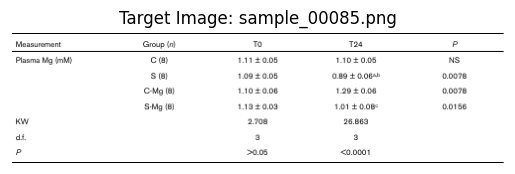

  → 8 rows, 5 cols

=== DEBUG CELLS ROW 1 ===
  col 0: span=1x1, x=0, y=18, w=96, h=17
  col 1: span=1x1, x=96, y=18, w=99, h=17
  col 2: span=1x1, x=196, y=18, w=103, h=17
  col 3: span=1x1, x=299, y=18, w=106, h=17
  col 4: span=1x1, x=406, y=18, w=96, h=17
  Cells: 40

=== ALL CELLS AFTER OCR ===
row 0, col 0: text='Measurcnent'
row 0, col 1: text='Group {n}'
row 0, col 2: text='T0'
row 0, col 3: text='T24'
row 0, col 4: text='p'
row 1, col 0: text='Plasma Mg (mM)'
row 1, col 1: text='C (8)'
row 1, col 2: text='1.110.05'
row 1, col 3: text='1.10 0.05'
row 1, col 4: text='NS'
row 2, col 0: text=''
row 2, col 1: text='S {8}'
row 2, col 2: text='1.090.05'
row 2, col 3: text='0.89 0.08 b'
row 2, col 4: text='0.0078'
row 3, col 0: text=''
row 3, col 1: text='C-Mg {8}'
row 3, col 2: text='1.100.08'
row 3, col 3: text='1.29 0.08'
row 3, col 4: text='0.0078'
row 4, col 0: text=''
row 4, col 1: text='S-Mg {B)'
row 4, col 2: text='1.130.03'
row 4, col 3: text='1.01 0.08'
row 4, col 4: text='0

In [ ]:
import random
from pathlib import Path
import torch
import matplotlib.pyplot as plt
# ── Pipeline hoàn chỉnh ───────────────────────────────────
def image_to_markdown_v3(image_path, model1, model2, device,
                          thresholds, img_size=384, upscale=2.5):
    orig_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = orig_img.size

    scale  = img_size / max(orig_w, orig_h)
    new_w, new_h = int(orig_w*scale), int(orig_h*scale)
    draft  = orig_img.resize((new_w, new_h), Image.BILINEAR)
    padded = Image.new("RGB", (img_size, img_size), (255,255,255))
    padded.paste(draft, (0,0))

    img_t = TF.to_tensor(padded).unsqueeze(0).to(device)
    model1.eval(); model2.eval()
    with torch.no_grad():
        p1 = torch.sigmoid(model1(img_t))
        p2 = torch.sigmoid(model2(img_t))
        preds = ((p1 + p2) / 2).squeeze(0).cpu().numpy()

    row_mask = (preds[0] > thresholds["row"]).astype(np.uint8)
    col_mask = (preds[1] > thresholds["col"]).astype(np.uint8)

    cells = masks_to_cell_boxes_v2(
        row_mask, col_mask,
        orig_w, orig_h, img_size,
        effective_w=new_w, effective_h=new_h,
        orig_img_pil=orig_img   
    )
    print(f"  Cells: {len(cells)}")

    cells = crop_and_ocr_fast(orig_img, cells, ocr, upscale=upscale)
    print("\n=== ALL CELLS AFTER OCR ===")
    for c in sorted(cells, key=lambda x: (x.row_idx, x.col_idx)):
        print(f"row {c.row_idx}, col {c.col_idx}: text='{c.text}'")
    return cells_to_markdown(cells), cells

TEST_IMG_DIR = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images")
target_pattern = "*00085*" # Tìm bất kỳ file nào chứa 00085
specific_images = list(TEST_IMG_DIR.glob(f"{target_pattern}.png"))

if not specific_images:
    specific_images = list(TEST_IMG_DIR.glob(f"{target_pattern}.jpg"))

if len(specific_images) == 0:
    raise FileNotFoundError(f"Không tìm thấy ảnh nào chứa '00085' trong {TEST_IMG_DIR}")

# Lấy file đầu tiên tìm được
selected_img_path = specific_images[0]
print(f"Đang xử lý ảnh: {selected_img_path.name}")

img = Image.open(selected_img_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Target Image: {selected_img_path.name}")
plt.show()

md, cells = image_to_markdown_v3(
    selected_img_path,
    model_best, model_last,   
    device,
    opt_thresholds,          
    upscale=2.5
)

print("\n=== Markdown Output ===")
print(md)

In [ ]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import time
from rapidfuzz import fuzz
import re

# 1. CÁC HÀM TÍNH ĐIỂM (Giữ nguyên chuẩn mực đánh giá)
def markdown_to_grid(md_str):
    if not md_str: return []
    lines = [l.strip() for l in md_str.split('\n') if l.strip() and '|' in l and '---' not in l]
    grid = [list(map(str.strip, l.strip('|').split('|'))) for l in lines]
    return grid

def super_clean(text):
    if not text: return ""
    clean_text = re.sub(r'[^a-zA-Z0-9]', '', str(text)).lower()
    return clean_text

def calculate_cell_accuracy(md_pred, md_gt):
    grid_p = markdown_to_grid(md_pred)
    grid_g = markdown_to_grid(md_gt)
    
    if not grid_g: return 0.0
    if not grid_p: return 0.0 

    rows_g = len(grid_g)
    cols_g = len(grid_g[0])
    total_cells_gt = rows_g * cols_g
    
    match_count = 0
    
    for r in range(rows_g):
        for c in range(cols_g):
            try:
                p_raw = grid_p[r][c] if r < len(grid_p) and c < len(grid_p[0]) else ""
                g_raw = grid_g[r][c]
                
                p_text = super_clean(p_raw)
                g_text = super_clean(g_raw)
                
                if not p_text and not g_text:
                    match_count += 1
                elif p_text and g_text:
                    if p_text == g_text or fuzz.ratio(p_text, g_text) > 80:
                        match_count += 1
            except Exception:
                continue 
                
    return (match_count / total_cells_gt) * 100

In [ ]:
# 2. CẤU HÌNH ĐƯỜNG DẪN & CHUẨN BỊ DỮ LIỆU
GT_FOLDER = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt"
IMG_FOLDER = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images")

# Lấy 200 mẫu (Nếu bạn muốn chạy HẾT toàn bộ thư mục, hãy xóa "[:200]")
SAMPLES = list(IMG_FOLDER.glob("*.png"))[:200]
if not SAMPLES:
    SAMPLES = list(IMG_FOLDER.glob("*.jpg"))[:200]

results = []

# 3. VÒNG LẶP ĐÁNH GIÁ CHÍNH
print(f"\n🚀 Bắt đầu chạy full đánh giá {len(SAMPLES)} samples trên Model U-Net...")
start_time = time.time()

for idx, sample_path in enumerate(tqdm(SAMPLES, desc="Đang xử lý")):
    filename = sample_path.stem
    gt_file = Path(GT_FOLDER) / f"{filename}.md"
    
    # Bỏ qua nếu không có file Ground Truth tương ứng
    if not gt_file.exists():
        continue
        
    try:
        # Gọi pipeline của bạn
        if 'thresholds' in ckpt:
            thresholds = ckpt['thresholds']
        else:
            thresholds = {'row':0.5, 'col':0.5, 'span':0.5}
            print("⚠️ Không tìm thấy thresholds, dùng mặc định 0.5")
        unet_md, _ = image_to_markdown_v3(str(sample_path), model_eval, device,thresholds, img_size=384)
        
        # Đọc Ground Truth
        with open(gt_file, 'r', encoding='utf-8') as f:
            gt_md = f.read()
            
        # Tính điểm Accuracy
        acc = calculate_cell_accuracy(unet_md, gt_md)
        
        results.append({
            "index": idx,
            "filename": filename,
            "accuracy": acc
        })
    except Exception as e:
        print(f"⚠️ Lỗi tại file {filename}: {e}")

# 4. TỔNG HỢP VÀ XUẤT BÁO CÁO
df_results = pd.DataFrame(results)
avg_acc = df_results['accuracy'].mean()
total_time = time.time() - start_time

print("\n" + "="*45)
print(f"📊 KẾT QUẢ TỔNG HỢP: MODEL U-NET ({len(df_results)} SAMPLES)")
print("="*45)
print(f"➤ Độ chính xác trung bình (Cell-level) : {avg_acc:.2f}%")
print(f"➤ Số file đạt xuất sắc (> 90%)         : {len(df_results[df_results['accuracy'] >= 90])}")
print(f"➤ Số file bị lỗi cấu trúc (< 50%)      : {len(df_results[df_results['accuracy'] < 50])}")
print(f"➤ Tổng thời gian chạy                  : {total_time:.2f} giây")
print(f"➤ Tốc độ trung bình                    : {total_time/len(df_results):.2f} giây/ảnh")
print("="*45)

# Lưu file kết quả để vẽ biểu đồ chéo với file của Docling
df_results.to_csv("unet_pipeline_eval_results.csv", index=False)
print("✅ Đã lưu kết quả chi tiết vào file: unet_pipeline_eval_results.csv")


🚀 Bắt đầu chạy full đánh giá 200 samples trên Model U-Net...


Đang xử lý:   0%|          | 0/200 [00:00<?, ?it/s]

⚠️ Ảnh quá nhỏ, đã scale lên 584×400
Ảnh gốc: 584×400px
  → 14 rows, 5 cols
Tổng cells: 67


Đang xử lý:   0%|          | 1/200 [00:08<26:38,  8.03s/it]

Ảnh gốc: 486×408px
  → 15 rows, 11 cols
Tổng cells: 147


...

⚠️ Ảnh quá nhỏ, đã scale lên 1045×400
Ảnh gốc: 1045×400px
  → 13 rows, 5 cols
Tổng cells: 65


Đang xử lý: 100%|█████████▉| 199/200 [31:57<00:11, 11.58s/it]

Ảnh gốc: 238×255px
  → 18 rows, 5 cols
Tổng cells: 90


Đang xử lý: 100%|██████████| 200/200 [32:02<00:00,  9.61s/it]



📊 KẾT QUẢ TỔNG HỢP: MODEL U-NET (200 SAMPLES)
➤ Độ chính xác trung bình (Cell-level) : 49.53%
➤ Số file đạt xuất sắc (> 90%)         : 0
➤ Số file bị lỗi cấu trúc (< 50%)      : 68
➤ Tổng thời gian chạy                  : 1923.19 giây
➤ Tốc độ trung bình                    : 9.62 giây/ảnh
✅ Đã lưu kết quả chi tiết vào file: unet_pipeline_eval_results.csv
